In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

raw_dir = PROJECT_ROOT / "data" / "raw"
processed_dir = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid")

In [2]:
fund_master = pd.read_csv(
    raw_dir / "01_fund_master.csv"
)

nav_history = pd.read_csv(
    processed_dir / "clean_nav_history.csv"
)

aum = pd.read_csv(
    raw_dir / "03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    raw_dir / "04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    raw_dir / "05_category_inflows.csv"
)

folio = pd.read_csv(
    raw_dir / "06_industry_folio_count.csv"
)

transactions = pd.read_csv(
    processed_dir /
    "clean_investor_transactions.csv"
)

portfolio = pd.read_csv(
    raw_dir / "09_portfolio_holdings.csv"
)

In [3]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [5]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [6]:
avg_nav = (
    nav_history
    .groupby("date")["nav"]
    .mean()
    .reset_index()
)

fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Across All Schemes (2022-2026)"
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()
/home/saurabh/anaconda3/lib/python3.11/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [7]:
fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.10,
    line_width=0
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [8]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [9]:
top5 = (
    fund_master
    .head(5)[["amfi_code","scheme_name"]]
)

top_nav = nav_history.merge(
    top5,
    on="amfi_code"
)

fig = px.line(
    top_nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trend of Top 5 Mutual Fund Schemes"
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [10]:
from pathlib import Path

charts_dir = PROJECT_ROOT / "charts"
charts_dir.mkdir(exist_ok=True)

In [11]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [12]:
top5 = fund_master[
    ["amfi_code", "scheme_name"]
].head(5)

top_nav = nav_history.merge(
    top5,
    on="amfi_code"
)

fig = px.line(
    top_nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trend of Top 5 Mutual Fund Schemes"
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



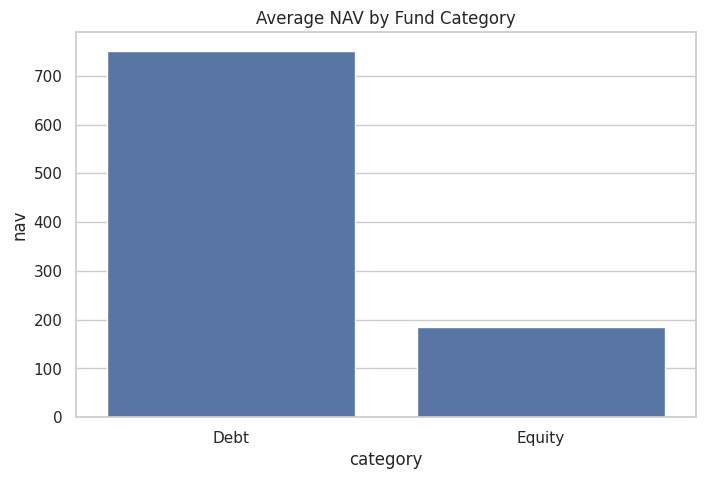

In [13]:
nav_fund = nav_history.merge(
    fund_master[
        ["amfi_code", "category"]
    ],
    on="amfi_code"
)

category_nav = (
    nav_fund
    .groupby("category")["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_nav,
    x="category",
    y="nav"
)

plt.title(
    "Average NAV by Fund Category"
)

plt.show()

In [14]:
charts_dir = PROJECT_ROOT / "charts"
charts_dir.mkdir(exist_ok=True)

In [15]:
plt.savefig(
    charts_dir / "avg_nav_category.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [16]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [17]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

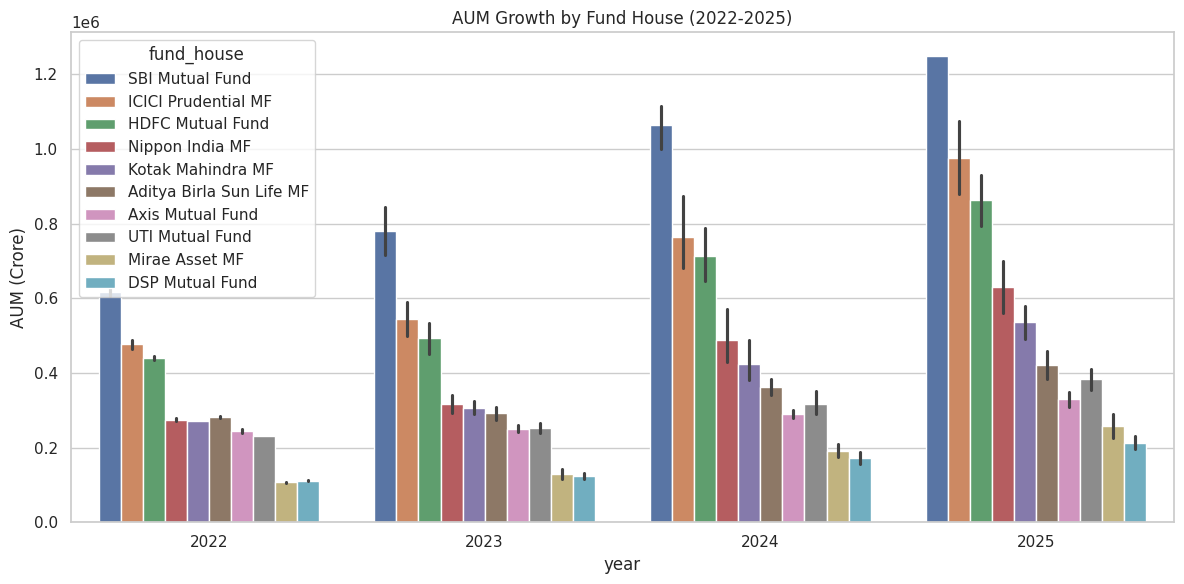

In [18]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.savefig(
    charts_dir / "aum_growth_by_house.png",
    bbox_inches="tight"
)

plt.show()

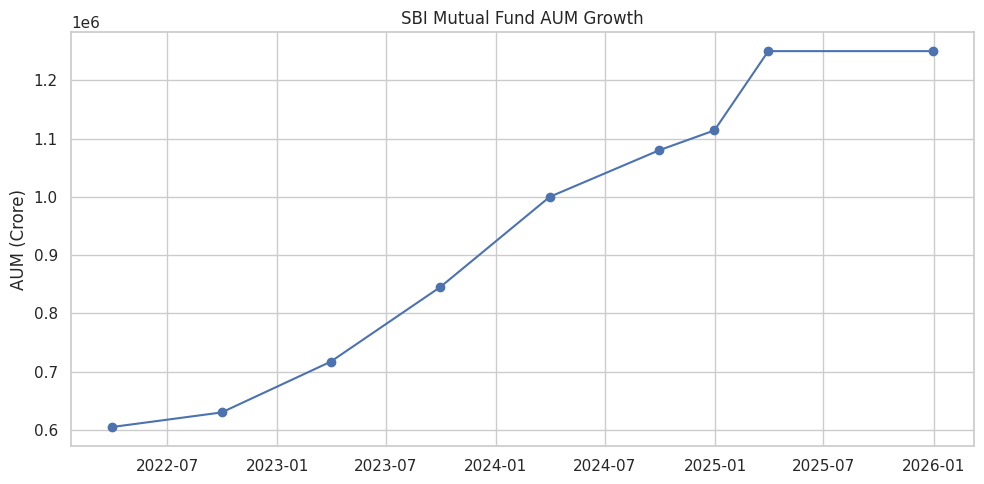

In [19]:
sbi = aum[
    aum["fund_house"] ==
    "SBI Mutual Fund"
]

plt.figure(figsize=(10,5))

plt.plot(
    sbi["date"],
    sbi["aum_crore"],
    marker="o"
)

plt.title(
    "SBI Mutual Fund AUM Growth"
)

plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.savefig(
    charts_dir / "sbi_aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [21]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [22]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

In [23]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [24]:
peak_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows with Peak Highlight"
)

fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=f"Peak: ₹{peak_row['sip_inflow_crore']:,} Cr",
    showarrow=True
)

fig.show()

/home/saurabh/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



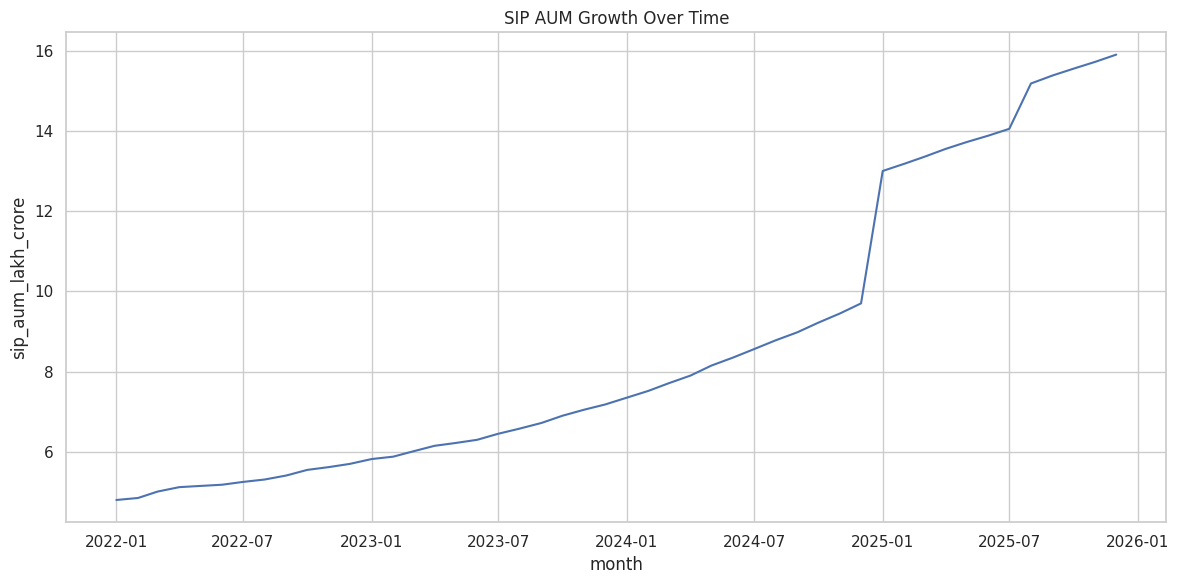

In [25]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_aum_lakh_crore"
)

plt.title(
    "SIP AUM Growth Over Time"
)

plt.tight_layout()

plt.savefig(
    charts_dir / "sip_aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [27]:
category_inflows.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [28]:
category_inflows["month"] = pd.to_datetime(
    category_inflows["month"]
)

In [29]:
heatmap_data = (
    category_inflows
    .pivot(
        index="category",
        columns="month",
        values="net_inflow_crore"
    )
)

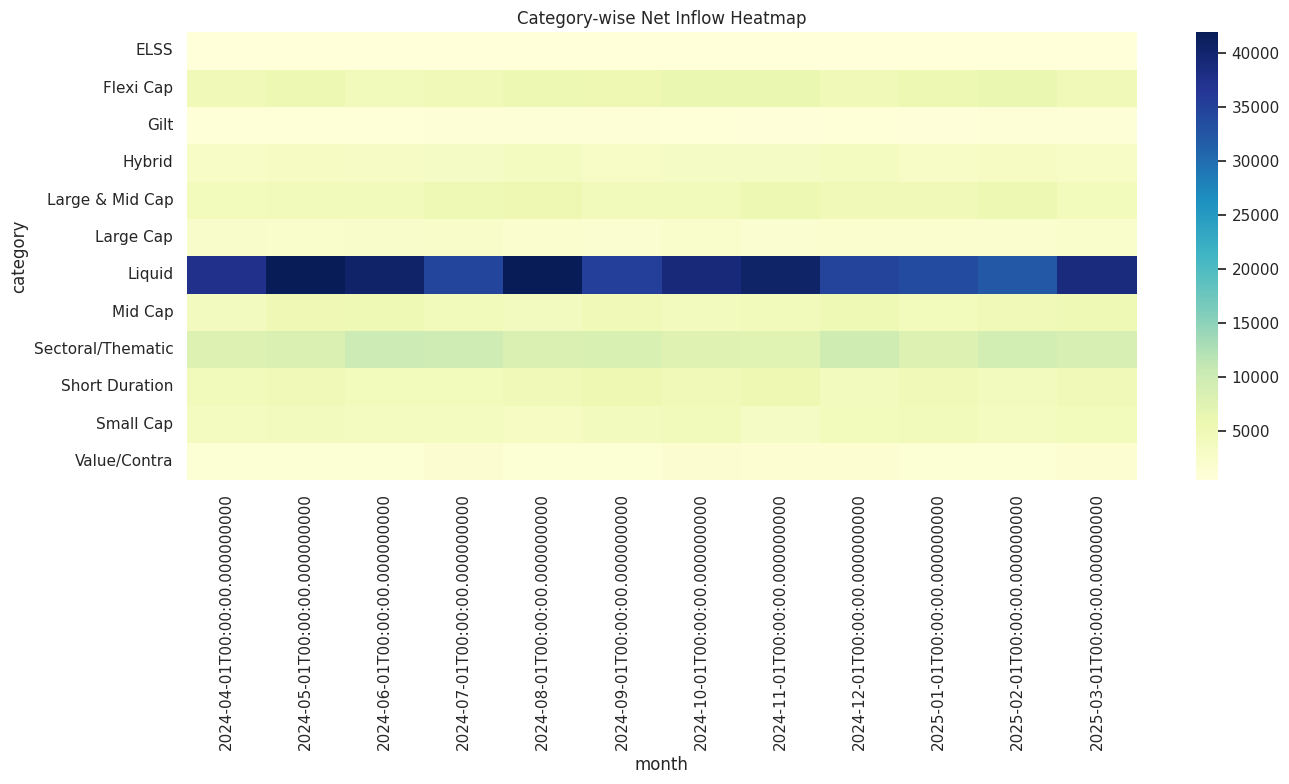

In [30]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.tight_layout()

plt.savefig(
    charts_dir /
    "category_inflow_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [31]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [32]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

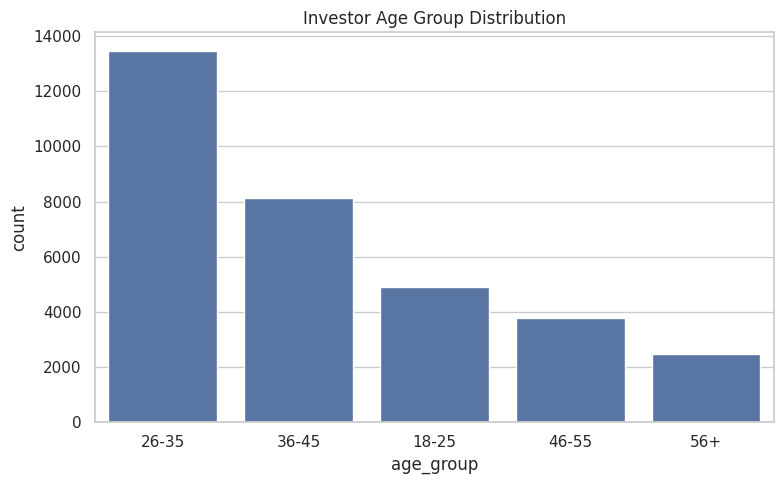

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="age_group",
    order=transactions["age_group"].value_counts().index
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()

plt.savefig(
    charts_dir / "age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

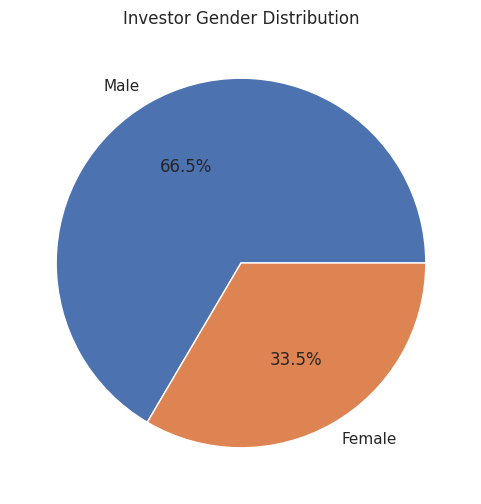

In [34]:
gender_counts = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.savefig(
    charts_dir / "gender_distribution.png",
    bbox_inches="tight"
)

plt.show()


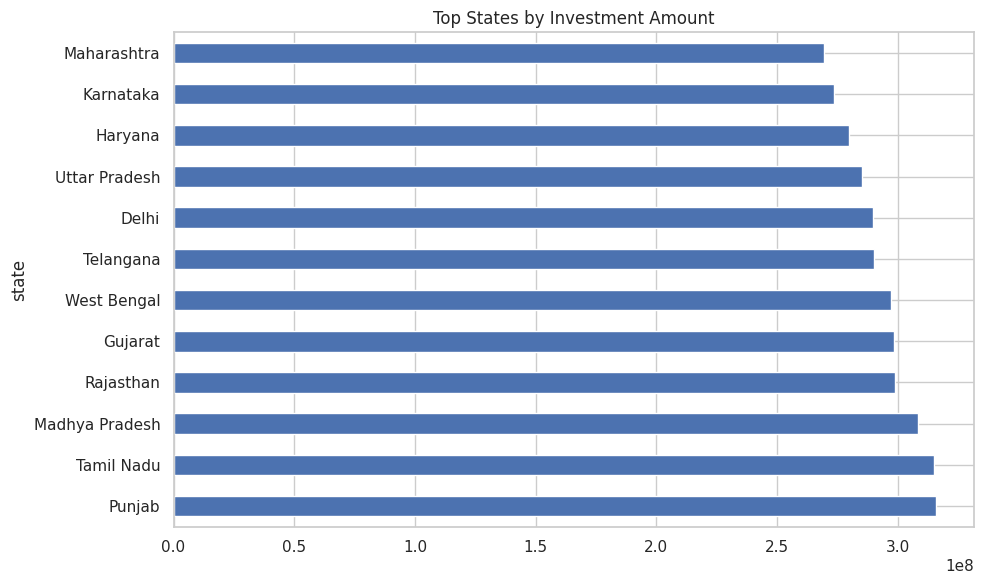

In [35]:
state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

state_investment.plot(kind="barh")

plt.title(
    "Top States by Investment Amount"
)

plt.tight_layout()

plt.savefig(
    charts_dir / "investment_by_state.png",
    bbox_inches="tight"
)

plt.show()

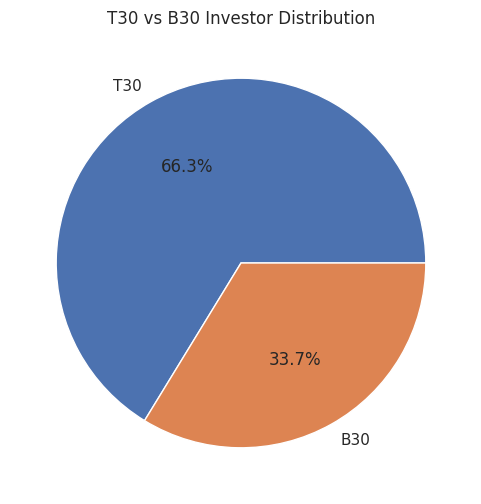

In [36]:
tier_counts = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.savefig(
    charts_dir / "city_tier_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [38]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

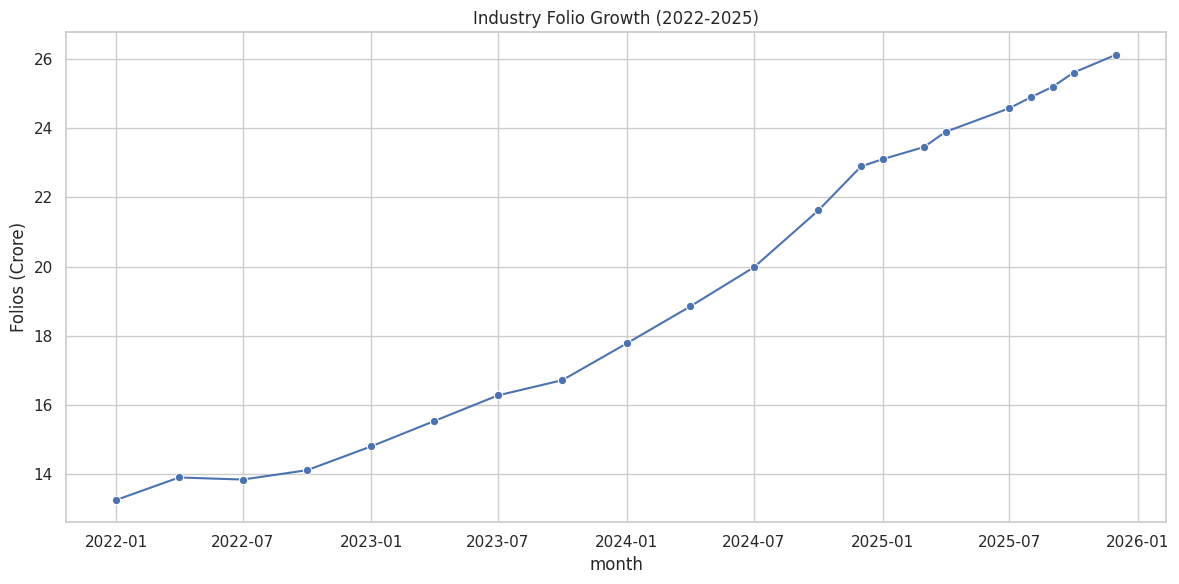

In [39]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.title(
    "Industry Folio Growth (2022-2025)"
)

plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig(
    charts_dir / "folio_growth.png",
    bbox_inches="tight"
)

plt.show()

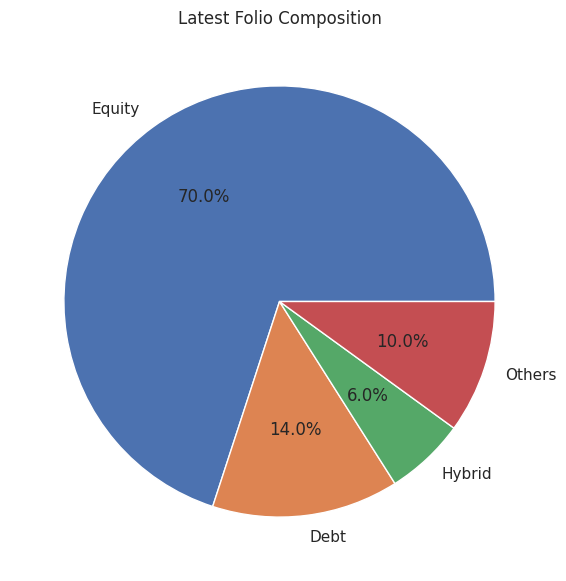

In [40]:
latest = folio.iloc[-1]

composition = pd.DataFrame({
    "Category": [
        "Equity",
        "Debt",
        "Hybrid",
        "Others"
    ],
    "Folios": [
        latest["equity_folios_crore"],
        latest["debt_folios_crore"],
        latest["hybrid_folios_crore"],
        latest["others_folios_crore"]
    ]
})

plt.figure(figsize=(7,7))

plt.pie(
    composition["Folios"],
    labels=composition["Category"],
    autopct="%1.1f%%"
)

plt.title(
    "Latest Folio Composition"
)

plt.savefig(
    charts_dir / "folio_composition.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [42]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [43]:
sector_alloc = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

sector_alloc = (
    sector_alloc
    .sort_values(
        "weight_pct",
        ascending=False
    )
)

In [44]:
fig = go.Figure(
    data=[
        go.Pie(
            labels=sector_alloc["sector"],
            values=sector_alloc["weight_pct"],
            hole=0.5
        )
    ]
)

fig.update_layout(
    title="Sector Allocation Across Equity Funds"
)

fig.show()

In [45]:
pip install kaleido


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [46]:
fig.write_image(
    charts_dir / "sector_allocation_donut.png"
)

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
pip install kaleido


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


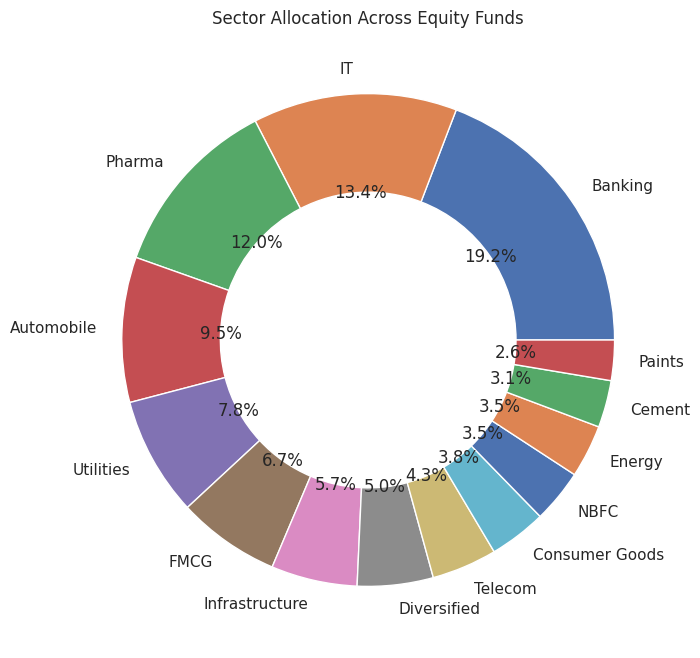

In [52]:
sector_alloc = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    charts_dir / "sector_allocation_donut.png",
    bbox_inches="tight"
)

plt.show()

In [53]:
sector_alloc = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

In [54]:
heatmap_data.columns = (
    pd.to_datetime(heatmap_data.columns)
    .strftime("%Y-%m")
)

In [55]:
import os

files = os.listdir(charts_dir)

print("Number of exported charts:", len(files))

for f in files:
    print(f)

Number of exported charts: 12
city_tier_distribution.png
folio_growth.png
age_group_distribution.png
sector_allocation_donut.png
folio_composition.png
category_inflow_heatmap.png
aum_growth_by_house.png
avg_nav_category.png
investment_by_state.png
sbi_aum_growth.png
gender_distribution.png
sip_aum_growth.png


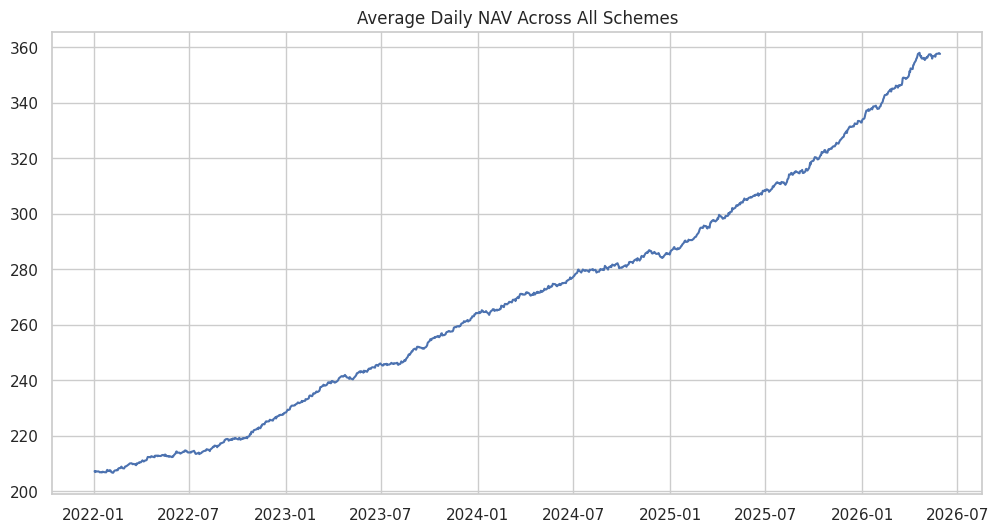

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
    avg_nav["date"],
    avg_nav["nav"]
)

plt.title(
    "Average Daily NAV Across All Schemes"
)

plt.savefig(
    charts_dir / "avg_daily_nav.png",
    bbox_inches="tight"
)

plt.show()

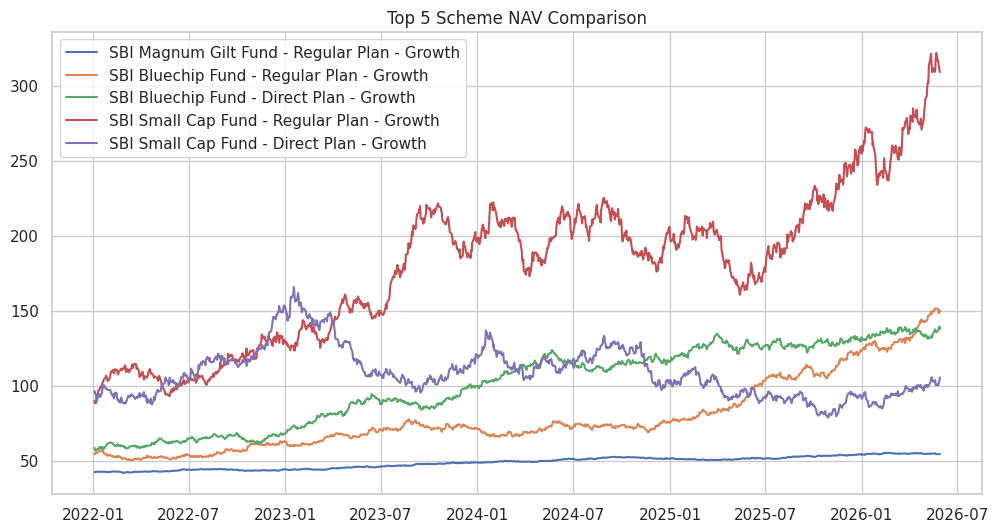

In [57]:
plt.figure(figsize=(12,6))

for scheme in top_nav["scheme_name"].unique():
    temp = top_nav[
        top_nav["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.legend()
plt.title(
    "Top 5 Scheme NAV Comparison"
)

plt.savefig(
    charts_dir / "top5_scheme_nav.png",
    bbox_inches="tight"
)

plt.show()

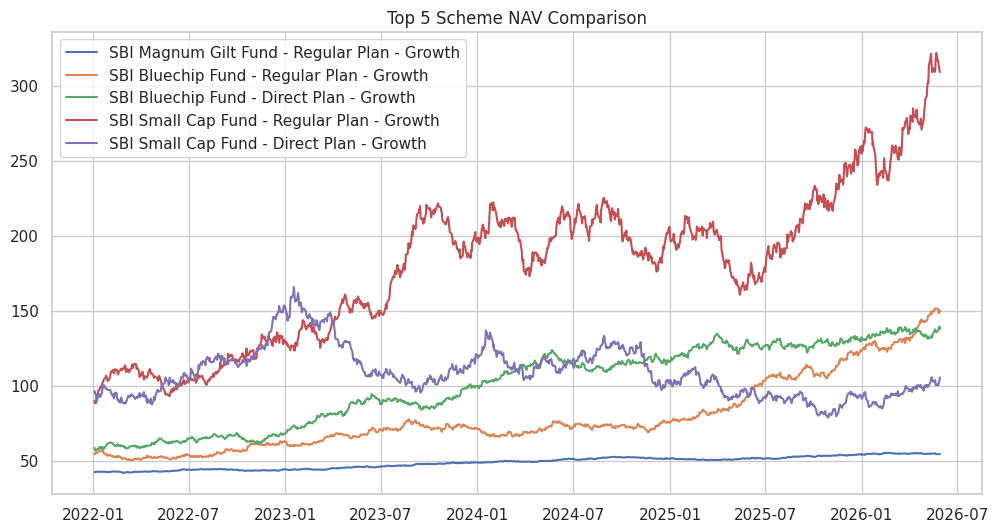

In [58]:
plt.figure(figsize=(12,6))

for scheme in top_nav["scheme_name"].unique():
    temp = top_nav[
        top_nav["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.legend()
plt.title(
    "Top 5 Scheme NAV Comparison"
)

plt.savefig(
    charts_dir / "top5_scheme_nav.png",
    bbox_inches="tight"
)

plt.show()

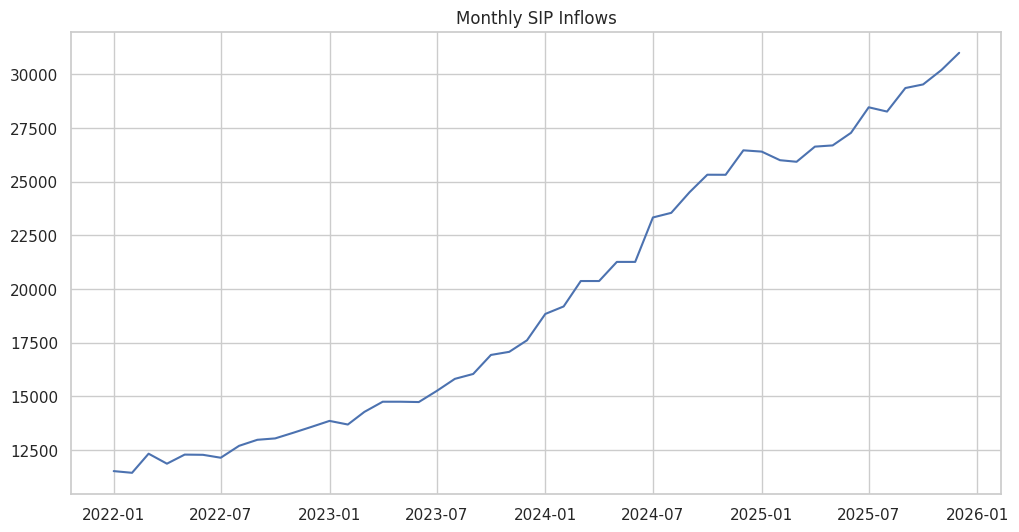

In [59]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title(
    "Monthly SIP Inflows"
)

plt.savefig(
    charts_dir / "sip_inflow_trend.png",
    bbox_inches="tight"
)

plt.show()

In [60]:
import os

print(len(os.listdir(charts_dir)))

15
